# **Wine Quality Prediction**

## Importing Dependencies

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn import svm

##Loading the dataset

In [ ]:
df = pd.read_csv('/content/WineQT.csv')
df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,0
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5,1
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5,2
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6,3
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1138,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6,1592
1139,6.8,0.620,0.08,1.9,0.068,28.0,38.0,0.99651,3.42,0.82,9.5,6,1593
1140,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5,1594
1141,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6,1595


In [ ]:
df.drop('Id',axis=1,inplace=True)
df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1138,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1139,6.8,0.620,0.08,1.9,0.068,28.0,38.0,0.99651,3.42,0.82,9.5,6
1140,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1141,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6


In [ ]:
df['quality'].value_counts()

,count
quality,
5,483
6,462
7,143
4,33
8,16
3,6


In [ ]:
df[df['quality'] == 7].describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,143.000000,143.000000,143.000000,143.000000,143.000000,143.000000,143.000000,143.000000,143.000000,143.000000,143.000000,143.0
mean,8.851049,0.393671,0.386573,2.760140,0.075217,14.538462,37.489510,0.996071,3.287133,0.743566,11.482634,7.0
std,2.105187,0.133795,0.197812,1.409444,0.030519,9.904842,36.743279,0.002292,0.151214,0.143681,0.980337,0.0
min,4.900000,0.120000,0.000000,1.200000,0.012000,3.000000,8.000000,0.990640,2.920000,0.390000,9.200000,7.0
25%,7.400000,0.300000,0.320000,2.000000,0.062000,7.000000,19.000000,0.994690,3.200000,0.655000,10.800000,7.0
50%,8.700000,0.360000,0.400000,2.300000,0.073000,12.000000,28.000000,0.995680,3.270000,0.740000,11.600000,7.0
75%,10.100000,0.480000,0.505000,2.800000,0.085000,18.500000,43.000000,0.997355,3.380000,0.840000,12.100000,7.0
max,15.600000,0.840000,0.760000,8.300000,0.358000,53.000000,289.000000,1.003200,3.780000,1.360000,14.000000,7.0


<Axes: >

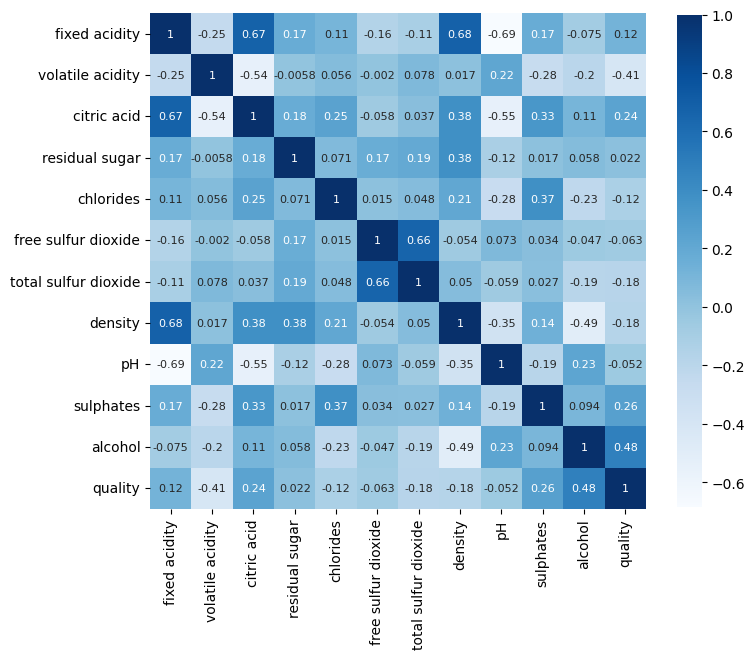

In [ ]:
df_corr = df.corr()
plt.figure(figsize=(8, 8))
sns.heatmap(df_corr,cbar=True,square=True,annot=True,cmap='Blues',annot_kws={'size':8},cbar_kws={"shrink": 0.8})

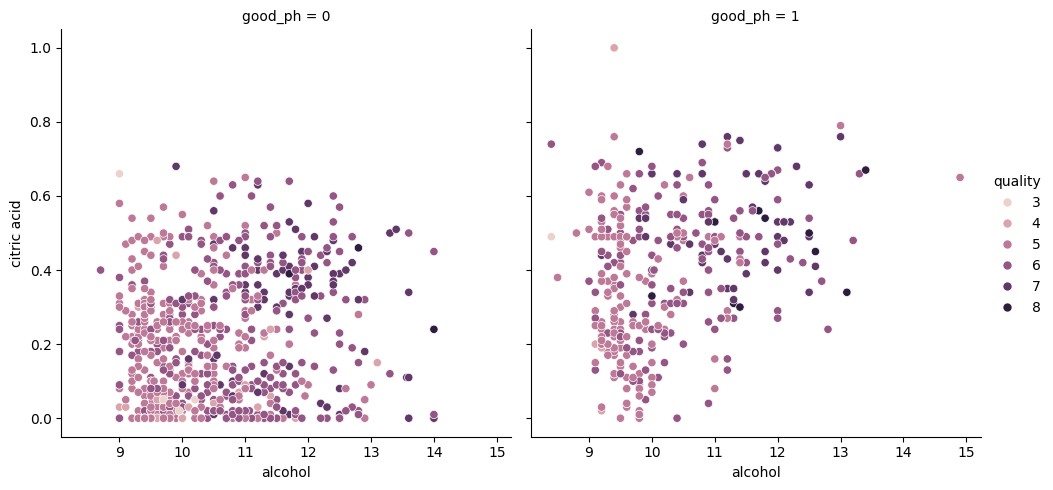

In [ ]:
df['good_ph'] = df['pH'].apply(lambda x: 1 if x < 3.25 else 0)
sns.relplot(x="alcohol",y="citric acid",col="good_ph",data=df,hue="quality")

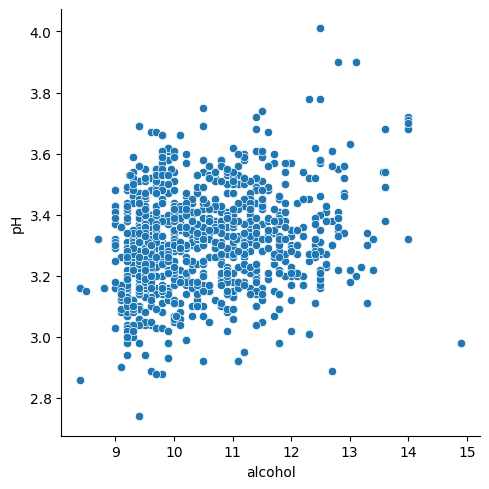

In [ ]:
sns.relplot(x="alcohol",y="pH",data=df)

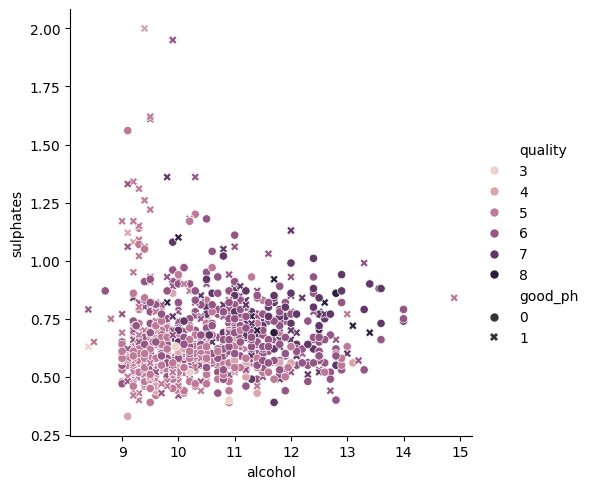

In [ ]:
sns.relplot(x="alcohol",y="sulphates",data=df,hue="quality",style="good_ph")

In [ ]:
df.drop('good_ph',axis=1,inplace=True)

In [ ]:
Y = df['quality'].apply(lambda x:1 if x > 6 else 0)
X = df.drop('quality',axis=1)
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2,random_state=42,stratify=Y)

##RandomForestClassifier Model


In [ ]:
model = RandomForestClassifier()
model.fit(X_train,Y_train)
X_train_prediction = model.predict(X_train);
X_test_prediction = model.predict(X_test);
print('Training data Accuracy : ',accuracy_score(Y_train,X_train_prediction))
print('Testing data Accuracy : ',accuracy_score(Y_test,X_test_prediction))
print(X_test_prediction)

Training data Accuracy :  1.0
Testing data Accuracy :  0.9213973799126638
[1 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0
 0 0 0 0 0 1 0 0 0 0 0 1 0 0 1 0 1 0 0 0 0 1 0 0 0 1 0 1 1 0 0 0 0 0 0 0 1
 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 1 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0
 0 0 0 0 0 0 0 1 0 0 1 1 0 0 0 0 0 0 1 0 0 1 0 0 0 0 1 0 0 0 0 0 0 0 0 0 1
 0 0 0 0 0 0 0]


##SVM Classifier

In [ ]:
kernel = ['linear','rbf','poly','sigmoid']
for i in range(len(kernel)):
  print("\n" + kernel[i] + "\n")
  model = svm.SVC(kernel=kernel[i])
  model.fit(X_train,Y_train)
  X_train_prediction = model.predict(X_train);
  X_test_prediction = model.predict(X_test);
  print('Training data Accuracy : ',accuracy_score(Y_train,X_train_prediction))
  print('Testing data Accuracy : ',accuracy_score(Y_test,X_test_prediction))


linear

Training data Accuracy :  0.8610503282275711
Testing data Accuracy :  0.8602620087336245

rbf

Training data Accuracy :  0.8632385120350109
Testing data Accuracy :  0.8602620087336245

poly

Training data Accuracy :  0.8632385120350109
Testing data Accuracy :  0.8602620087336245

sigmoid

Training data Accuracy :  0.8610503282275711
Testing data Accuracy :  0.8602620087336245
